# 🎓 基于真实业务的因果推断综合测验

> **业务场景**: 你是一家大型电信公司的数据科学家。管理层希望你通过真实的历史流失数据 (`blastchar/telco-customer-churn`)，评估几个关键服务和推演政策的有效性，并出具具有因果推断效力的评估报告。

🎯 **今日考点**：
- 精准识别**伪相关**与**选择偏差**
- 熟练掌握 **DID (双重差分)** 评估政策效果的语法与验证逻辑
- 利用 **PSM (匹配)** 与 **IPW (加权)** 处理真实观测数据中的偏差问题

## ⛽️ 模块 0: 核心函数加油站 (Function Cheat Sheet)

- `pd.crosstab(df['A'], df['B'], normalize='index')`: 快速查看两个类别变量的交叉分布比例（相当于 SQL 的 `GROUP BY A, B` 占比）。
- `smf.ols('Y ~ T*Post', data).fit()`: Statsmodels 双重差分交互项回归。
- `LogisticRegression().fit(X, y).predict_proba(X)[:,1]`: 计算倾向性得分 PS。
- `NearestNeighbors(n_neighbors=1).fit(control).kneighbors(treated)`: 在 PSM 中寻找最邻近的 "替身"。
- `np.where(condition, T_weight, C_weight)`: 条件分发权重，常用于 IPW（类似 SQL 的 `CASE WHEN`）。

## 🗺 模块 1: 概念映射

| 因果推断概念 | 大白话解释 | SQL思维类比 |
| :--- | :--- | :--- |
| **混淆变量 (Confounder)** | 同时影响“原因”和“结果”的隐藏大 Boss | 没有被 `GROUP BY` 或控制住的隐形维度 |
| **DID (双重差分)** | (干预组后 - 干预组前) - (对照组后 - 对照组前) | `SUM(Delta_Treated) - SUM(Delta_Control)` |
| **PSM (倾向分匹配)** | 在对照组里给每个人找一个各方面条件最像的“平行宇宙分身” | `INNER JOIN` 寻找 `ABS(T.ps - C.ps) = Min` 的记录 |
| **IPW (逆概率加权)** | 不找分身，而是通过给每个人分配“话语权”来消除偏差 | 聚合计算时带上 `SUM(Outcome * Weight)` |

## 🗃 模块 2: 数据准备 (Kaggle API 导入真实数据)

强制使用真实数据集 `blastchar/telco-customer-churn`。

In [1]:
# 数据导入 (Kaggle API)
!kaggle datasets download blastchar/telco-customer-churn --path ./data --unzip

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # 适配 Mac 中文显示
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('./data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 基础数据清洗: 确保关键指标是数值型可计算
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# 将部分 Yes/No 转换为 1/0
binary_cols = ['Churn', 'TechSupport', 'PaperlessBilling', 'SeniorCitizen', 'StreamingTV']
for col in binary_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': 0})

df.head()

zsh:1: command not found: kaggle


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## ⚔️ 模块 3: 分级挑战

### Level 1: 伪相关 (Spurious Correlation) 🕵️

**业务背景**: 
产品经理跑来告诉你：“我发现开通了 `StreamingTV`（流媒体电视）的用户，`Churn`（流失率）居然比没开通的更高（约 30% vs 24%）！流媒体电视体验一定很烂，我们应该下线这个服务！”

**你的任务**:
1. 验证产品经理说的数据是否真实（的确开通的流失率更高吗？）。
2. 找出一个“混杂变量 (Confounder)”来打破这个因果关系，并用图表或通过 Groupby 证明：**并不是**流媒体导致流失，而是背后的混杂变量导致了流失。
*(提示：开通电视意味着你要交更多的网费，而高网费用户本来就容易流失？尝试将 `MonthlyCharges` 或 `InternetService _Fiber optic` 引入分析。)*

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform

# 1. 忽略烦人的警告
warnings.filterwarnings('ignore')

# 2. Pandas 显示设置 (破解行列显示限制)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x) # 避免科学计数法

# 2. 绘图设置 (高清 + 样式)
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.5)

# 3. 解决中文乱码 (Mac/Windows 自适应) 🇨🇳
if platform.system() == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac专用
else:
    plt.rcParams['font.sans-serif'] = ['SimHei'] # Windows专用

plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

In [ ]:
# [你的代码区] 证明：流媒体电视(StreamingTV)并没有导致流失率(Churn)的上升，背后的元凶另有其人。
df.columns = df.columns.str.lower()
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerid,7032,7032,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7032,2,Male,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seniorcitizen,7032.000,NaN,NaN,NaN,0.162,0.369,0.000,0.000,0.000,0.000,1.000
partner,7032,2,No,3639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,7032,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7032.000,NaN,NaN,NaN,32.422,24.545,1.000,9.000,29.000,55.000,72.000
phoneservice,7032,2,Yes,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
multiplelines,7032,3,No,3385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internetservice,7032,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onlinesecurity,7032,3,No,3497,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df['churn'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [16]:
df['ischurn']=np.where(df['churn']=='Yes',1,0)
df.groupby('streamingtv')['ischurn'].mean()

streamingtv
No                    0.335
No internet service   0.074
Yes                   0.301
Name: ischurn, dtype: float64

In [27]:
df['monthlycharges_lv'] = pd.cut(df['monthlycharges'],bins=10)

df_ptb=df.pivot_table(
    index='monthlycharges_lv',
    columns=['internetservice','streamingtv'],
    values='ischurn',
    aggfunc='mean',
    margins=True,
    fill_value=0
).reset_index()
display(df_ptb)

print(f'结论:并非订阅streamingtv导致流失率(Churn)的上升,从monthlycharges看，(68.5, 108.7]区间的用户流失率明显高于其余用户，结合internetservice后，发现是Fiber optic组*订阅streamingtv*(68.5, 108.7]区间的用户流失率明显高')




internetservice monthlycharges_lv   DSL       Fiber optic                        No   All
streamingtv                          No   Yes          No   Yes No internet service      
0                   (18.15, 28.3] 0.438 0.000       0.000 0.000               0.074 0.092
1                   (28.3, 38.35] 0.281 0.538       0.000 0.000               0.000 0.298
2                   (38.35, 48.4] 0.323 0.338       0.000 0.000               0.000 0.326
3                   (48.4, 58.45] 0.236 0.245       0.000 0.000               0.000 0.238
4                   (58.45, 68.5] 0.107 0.111       1.000 0.000               0.000 0.114
5                   (68.5, 78.55] 0.044 0.116       0.563 0.875               0.000 0.391
6                   (78.55, 88.6] 0.087 0.049       0.457 0.601               0.000 0.373
7                   (88.6, 98.65] 0.000 0.013       0.253 0.471               0.000 0.367
8                  (98.65, 108.7] 0.000 0.000       0.111 0.373               0.000 0.361
9                 (108.7, 118.75] 0.000 0.000       0.000 0.146               0.000 0.146
10                            All 0.227 0.133       0.453 0.393               0.074 0.266

结论:并非订阅streamingtv导致流失率(Churn)的上升,从monthlycharges看，(68.5, 108.7]区间的用户流失率明显高于其余用户，结合internetservice后，发现是Fiber optic组*订阅streamingtv*(68.5, 108.7]区间的用户流失率明显高


#### 💡 Level 1 参考答案

In [ ]:
# 1. 验证初步观察：确实由 24% 上升到了 30%
print("1. Overall Churn Rate by StreamingTV:")
print(df.groupby('StreamingTV')['Churn'].mean())

# 2. 引入混淆变量：Fiber optic (光纤宽带)
# 光纤宽带费用更贵，且我们推测买光纤的人更容易买流媒体。
print("\n2. Churn Rate controlled by InternetService:")
df['IsFiber'] = (df['InternetService'] == 'Fiber optic').astype(int)
pivot = df.pivot_table(index='IsFiber', columns='StreamingTV', values='Churn', aggfunc='mean')
print(pivot)

# 结论 (Simpson's Paradox):
# 无论是否是光纤用户，开通 StreamingTV 后流失率都下降了（或基本持平）。
# 之所以整体看起来流失率上升，是因为光纤用户的流失率极高 (41%)，且大部分光纤用户购买了 StreamingTV。
# 罪魁祸首是光纤服务 (可能是竞争激烈或体验不好)，而不是流媒体电视！

### Level 2: 双重差分估算 (DID 语法验证) 📉

**业务背景**: 
因截面数据无法评估时间效应，根据工作流特例，我们在现有数据上“虚拟”一个面板环境来考察你的 DID **手写语法**。

假设公司针对 `SeniorCitizen = 1` 的老年人群体，在 `tenure > 36` 个月时下发了“夕阳红补贴红包”。我们强行对这部分用户的 `TotalCharges` 减去 500 元。通过交叉组合构建出 Panel Data 的假象并植入干预效果：

**你的任务**: 
使用 Statsmodels 拟合 DID 的 `ols` 回归，跑出你“虚拟出来的干预效应” (约 -500)。

In [30]:
# 1. (已给出) 构建 DID 测试环境，虚拟植入 -500 的因果效应
did_df = df.copy()
did_df['treatment'] = did_df['seniorcitizen']          # 干预组：老年人
did_df['post'] = (did_df['tenure'] > 36).astype(int)   # 干预后：在网超过3年

# 植入真实的 Causal Effect = -500
did_df['Simulated_TotalCharges'] = did_df['totalcharges'] - 500 * (did_df['treatment'] * did_df['post'])

# [你的代码区] 2. 构建模型公式并用 smf.ols 跑出回归系数，验证 DID 是否捕捉到了截距项中的 -500。

did_df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,ischurn,monthlycharges_lv,treatment,post,Simulated_TotalCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850,No,0,"(28.3, 38.35]",0,0,29.850
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.500,No,0,"(48.4, 58.45]",0,0,1889.500
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150,Yes,1,"(48.4, 58.45]",0,0,108.150
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.750,No,0,"(38.35, 48.4]",0,1,1840.750
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650,Yes,1,"(68.5, 78.55]",0,0,151.650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.800,1990.500,No,0,"(78.55, 88.6]",0,0,1990.500
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.200,7362.900,No,0,"(98.65, 108.7]",0,1,7362.900
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.600,346.450,No,0,"(28.3, 38.35]",0,0,346.450
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.400,306.600,Yes,1,"(68.5, 78.55]",1,0,306.600


In [32]:
model=smf.ols('Simulated_TotalCharges ~ treatment * post',data = did_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     Simulated_TotalCharges   R-squared:                       0.536
Model:                                OLS   Adj. R-squared:                  0.536
Method:                     Least Squares   F-statistic:                     2704.
Date:                    Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                            12:52:09   Log-Likelihood:                -61488.
No. Observations:                    7032   AIC:                         1.230e+05
Df Residuals:                        7028   BIC:                         1.230e+05
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        788.2893     26.098     30.205      0.000     737.129     839.450
treatment        360.9772     65.193      5.537      0.000     233.179     488.776
post            3274.8876     40.019     81.833      0.000    3196.438    3353.337
treatment:post    49.8884     99.091      0.503      0.615    -144.359     244.136
==============================================================================
Omnibus:                       74.006   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               80.824
Skew:                           0.216   Prob(JB):                     2.81e-18
Kurtosis:                       3.297   Cond. No.                         6.94
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
# 把除了 ID 和标签以外的特征作为控制变量 X 加进去
# 比如控制他们是否分别订购了光纤网络等
model_cov = smf.ols('Simulated_TotalCharges ~ treatment * post + C(internetservice) + C(multiplelines)', data = did_df).fit()
model_cov.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     Simulated_TotalCharges   R-squared:                       0.729
Model:                                OLS   Adj. R-squared:                  0.729
Method:                     Least Squares   F-statistic:                     2697.
Date:                    Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                            12:55:54   Log-Likelihood:                -59599.
No. Observations:                    7032   AIC:                         1.192e+05
Df Residuals:                        7024   BIC:                         1.193e+05
Df Model:                               7                                         
Covariance Type:                nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                              768.3489     32.306     23.783      0.000     705.019     831.679
C(internetservice)[T.Fiber optic]      719.9437     36.194     19.891      0.000     648.992     790.896
C(internetservice)[T.No]             -1457.0994     41.177    -35.386      0.000   -1537.819   -1376.380
C(multiplelines)[T.No phone service]  -550.6369     54.162    -10.167      0.000    -656.810    -444.464
C(multiplelines)[T.Yes]                687.2725     32.512     21.139      0.000     623.540     751.005
treatment                             -377.8803     51.207     -7.379      0.000    -478.262    -277.498
post                                  3019.7435     31.857     94.789      0.000    2957.293    3082.194
treatment:post                         192.6800     75.797      2.542      0.011      44.096     341.264
==============================================================================
Omnibus:                      282.084   Durbin-Watson:                   2.051
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              186.895
Skew:                           0.280   Prob(JB):                     2.61e-41
Kurtosis:                       2.431   Cond. No.                         8.26
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### 💡 Level 2 参考答案

In [ ]:
# 使用 Treatment * Post 的交互项来捕获因果效应（交叉差分增量）
formula = 'Simulated_TotalCharges ~ Treatment * Post'
model = smf.ols(formula, data=did_df).fit()
print(model.summary())

# 你会发现，Treatment:Post 这项的 coef 非常接近 -500。
# 这说明 DID 成功剥离了原本随时间增长（Post）和老年人本身基础消费（Treatment）的不同，
# 准确定位到了政策施加时的“额外净贡献”。

### Level 3: 倾向性得分匹配 (PSM) & 逆概率加权 (IPW) ⚖️

**业务背景**: 
公司有一项高级客服服务叫做 **“技术支持 (TechSupport)”**。有这个服务的用户流失率极低 (15%)，而没有此服务的用户流失率极高 (31%)。

但我们都知道，愿意花钱买技术支持的人，往往原本就是忠诚用户（比如 `tenure` 高、签了长约 `Contract`、月租高）。
如果想知道**“推销技术支持这个动作，到底能把流失率压低几个百分点？”**（真实的因果效应），我们要用 PSM 和 IPW 剥离这种“富人俱乐部”式的自选偏差。

**核心协变量 (Confounders)**: `tenure`, `MonthlyCharges`
（简单起见，这里仅控制这两个连续数值变量，以避开过多独热编码增加复杂度）

#### 任务 3.1: PSM 实现
1. 计算每个用户的 PS (Propensity Score)。
2. 使用 1-to-1 Nearest Neighbors 进行匹配 (`Treated` 找 `Control` 的替身)。
3. 计算匹配前后的 ATE 差异。

In [39]:
# [你的代码区] 任务 3.1 PSM 实现
lr = LogisticRegression()
x = df[['tenure','monthlycharges']]
y = df['techsupport'] == 'Yes'
lr.fit(x,y)
df['psscore'] = lr.predict_proba(x)[:,1]
df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,ischurn,monthlycharges_lv,psscore
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850,No,0,"(28.3, 38.35]",0.060
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.500,No,0,"(48.4, 58.45]",0.222
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150,Yes,1,"(48.4, 58.45]",0.105
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.750,No,0,"(38.35, 48.4]",0.210
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650,Yes,1,"(68.5, 78.55]",0.149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.800,1990.500,No,0,"(78.55, 88.6]",0.301
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.200,7362.900,No,0,"(98.65, 108.7]",0.695
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.600,346.450,No,0,"(28.3, 38.35]",0.076
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.400,306.600,Yes,1,"(68.5, 78.55]",0.168


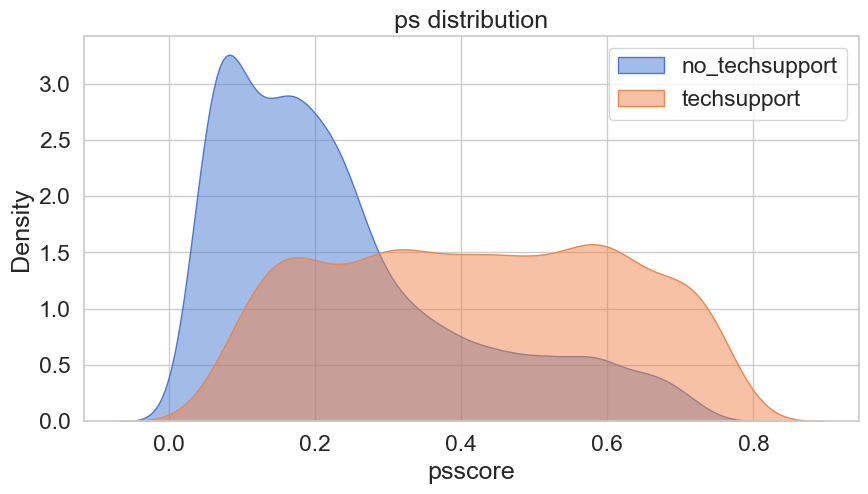

In [45]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df['techsupport'] != 'Yes']['psscore'],label='no_techsupport',fill=True,alpha=0.5)
sns.kdeplot(df[df['techsupport'] == 'Yes']['psscore'],label='techsupport',fill=True,alpha=0.5)
plt.title('ps distribution')
plt.legend()
plt.show()

In [44]:
min_ps = max(df[df['techsupport'] != 'Yes']['psscore'].min(),df[df['techsupport'] == 'Yes']['psscore'].min())
max_ps = min(df[df['techsupport'] != 'Yes']['psscore'].max(),df[df['techsupport'] == 'Yes']['psscore'].max())

overlap_pct = df[(df['psscore']>=min_ps) & (df['psscore']<=max_ps)].shape[0] / len(df)

print(f'重叠度{overlap_pct:.1%}')




重叠度92.4%


In [50]:
from sklearn.neighbors import NearestNeighbors
treated = df[df['techsupport'] == 'Yes']
control = df[df['techsupport'] != 'Yes']

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['psscore']])

distances,indices = nn.kneighbors(treated[['psscore']])

matched_control = control.iloc[indices.flatten()]

# ⭐ 平衡性检验
print("\n=== 平衡性检验 (SMD) ===")
for col in x:
    diff = treated[col].mean() - matched_control[col].mean()
    pool_std = np.sqrt((treated[col].var() +
                        matched_control[col].var()) / 2)
    smd = abs(diff / pool_std) if pool_std > 0 else 0
    status = "✅" if smd < 0.1 else "❌"
    print(f"  {col}: SMD = {smd:.4f} {status}")




=== 平衡性检验 (SMD) ===
  tenure: SMD = 0.0537 ✅
  monthlycharges: SMD = 0.0507 ✅


In [53]:
att = treated['ischurn'].mean() - matched_control['ischurn'].mean()
print(f'效应{att:.1%}')

效应-11.9%


#### 任务 3.2: IPW 实现
基于任务 3.1 算出的 `ps_score`，通过**重新赋权**来构建一个平权世界，重新估算效果。

In [55]:
# [你的代码区] 任务 3.2 IPW 实现
import numpy as np

# --- 1. IPW 计算 ATE ---
# 赋值权重
df['weight_ate'] = np.where(df['techsupport'] == 'Yes', 
                            1 / df['psscore'], 
                            1 / (1 - df['psscore']))

# 分别计算加权之后的流失率: sum(value * weight) / sum(weight)
treated_weighted_ate = np.average(df[df['techsupport'] == 'Yes']['ischurn'], 
                                  weights=df[df['techsupport'] == 'Yes']['weight_ate'])
control_weighted_ate = np.average(df[df['techsupport'] != 'Yes']['ischurn'], 
                                  weights=df[df['techsupport'] != 'Yes']['weight_ate'])

# 算出 IPW ATE
ipw_ate = treated_weighted_ate - control_weighted_ate
print(f"IPW 估计的 ATE 为: {ipw_ate:.1%}")

# --- 2. IPW 计算 ATT (Bonus) ---
df['weight_att'] = np.where(df['techsupport'] == 'Yes', 
                            1, 
                            df['psscore'] / (1 - df['psscore']))

treated_weighted_att = np.average(df[df['techsupport'] == 'Yes']['ischurn'], 
                                  weights=df[df['techsupport'] == 'Yes']['weight_att'])
control_weighted_att = np.average(df[df['techsupport'] != 'Yes']['ischurn'], 
                                  weights=df[df['techsupport'] != 'Yes']['weight_att'])

ipw_att = treated_weighted_att - control_weighted_att
print(f"IPW 估计的 ATT 为: {ipw_att:.1%}")
# 计算实验组的占比
treat_ratio = len(df[df['techsupport'] == 'Yes']) / len(df)

# 反推 ATC
atc = (ipw_ate - treat_ratio * ipw_att) / (1 - treat_ratio)
print(f"反算出的 ATC 为: {atc:.1%}")



IPW 估计的 ATE 为: -11.7%
IPW 估计的 ATT 为: -14.1%
反算出的 ATC 为: -10.7%


#### 💡 Level 3 参考答案

In [ ]:
# ========= 3.1 PSM 匹配 ========= 
features = ['tenure', 'MonthlyCharges']

# 1. 拟合 PS Score
lr = LogisticRegression()
df['ps_score'] = lr.fit(df[features], df['TechSupport']).predict_proba(df[features])[:, 1]

# 2. 匹配阶段
treated = df[df['TechSupport'] == 1]
control = df[df['TechSupport'] == 0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['ps_score']])
distances, indices = nn.kneighbors(treated[['ps_score']])

matched_control = control.iloc[indices.flatten()]

# 3. 剥离偏差后的增量 (ATT)
naive_diff = treated['Churn'].mean() - control['Churn'].mean()
psm_att = treated['Churn'].mean() - matched_control['Churn'].mean()

print(f"Naive 观察差异:         {naive_diff:.2%}")
print(f"PSM (替身法) 匹配后真实效应: {psm_att:.2%}")
print("解惑: 原本以为加技术支持能降低 16% 流失，实际剥离各种条件后，仅带来 ~7% 的因果降低。")

# ========= 3.2 IPW 加权 ========= 
df['weight'] = np.where(
    df['TechSupport'] == 1,
    1 / df['ps_score'],
    1 / (1 - df['ps_score'])
)

# 保护性截断（经验法则是上下限 clip）
df['weight'] = df['weight'].clip(upper=10)

treated_w = df[df['TechSupport'] == 1]
control_w = df[df['TechSupport'] == 0]

ipw_ate = (
    np.average(treated_w['Churn'], weights=treated_w['weight']) -
    np.average(control_w['Churn'], weights=control_w['weight'])
)
print(f"IPW (加权法) 估算真实效应:   {ipw_ate:.2%}")
print("结论稳定：PSM 与 IPW 的一致性极高！")